In [2]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset files:", path)

Resuming download from 1234173952 bytes (1229191483 bytes left)...
Resuming download to C:\Users\lokesh\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\2.archive (1234173952/2463365435) bytes left.


100%|██████████| 2.29G/2.29G [00:27<00:00, 44.6MB/s]

Extracting files...


Dataset files: C:\Users\lokesh\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [ ]:
import os
path = r"kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2"
print("Contents:", os.listdir(path))

data_dir = os.path.join(path, "chest_xray")

Contents: ['chest_xray']


In [3]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118 --default-timeout=1000

Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
import torch

# make sure gpu is available
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from pytorch_msssim import ssim

import numpy as np

transform = transforms.Compose([
    transforms.Resize((64, 64)),  # img dimensions, reshape to 64 x 64
    transforms.ToTensor(), # all values [0, 1]
])

train_path = os.path.join(data_dir, "train")
test_path = os.path.join(data_dir, "test")

train_dataset = ImageFolder(root=train_path, transform=transform)
test_dataset = ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}") 

Batch shape: torch.Size([64, 3, 64, 64])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=512, in_channels=3): 
        super(VAE, self).__init__()

        # ENCODER
        # padding (K - 1)/2 for smooth halving in down sampling
        self.encoder = nn.Sequential(
            
            # 64 -> 64
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            # 64 -> 64
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),

            # 64 -> 32
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            
            # 32 -> 16
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            
            # 16 -> 8
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),
            
            # 8 -> 4
            nn.Conv2d(512, 1024, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU()
            
        )

        # LATENT SPACE
        self.fc_mu = nn.Linear(1024 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(1024 * 4 * 4, latent_dim)
        self.fc_de = nn.Linear(latent_dim, 1024 * 4 * 4)

        # DECODER
        self.decoder = nn.Sequential(

            # 4 -> 8
            nn.ConvTranspose2d(1024, 512, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),
            
            # 8 -> 16
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            
            # 16 -> 32
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            
            # 32 -> 64
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),

            # 64 -> 64
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            
            # 64 -> 64
            nn.Conv2d(32, in_channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # 1. Encode
        x = self.encoder(x)
        x = x.view(x.size(0), -1)

        # 2. Latent Space
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        #log_var = torch.clamp(log_var, min=-10, max=10)
        z = self.reparameterize(mu, log_var)

        # 3. Decode
        x = self.fc_de(z)
        x = x.view(x.size(0), 1024, 4, 4)
        x = self.decoder(x)
        
        return x, mu, log_var

In [6]:
# model init
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
def loss_func(new_x, x, mu, logvar, alpha = 0.84):

    # note that all losses are averaged by batch size
    l1_loss = F.l1_loss(new_x, x, reduction='sum') / x.size(0)

    # calculate SSIM for image (returns 0 - 1)
    ssim_val = ssim(new_x, x, data_range=1.0, size_average=True)
    ssim_loss_mean = 1.0 - ssim_val
    
    # for mean pixel wise error like mse, we can scale up ssim by multiplyinh by pixel count
    pixels_per_image = x.size(1) * x.size(2) * x.size(3)
    ssim_loss_summed = ssim_loss_mean * pixels_per_image
    
    # SSIM + MAE loss is our entire reconstruction loss
    recons_loss = (alpha * ssim_loss_summed) + ((1.0 - alpha) * l1_loss)

    # mean KLD loss
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recons_loss, kld_loss

In [8]:
def get_beta(epoch, target_beta):
    # we increase beta step by step till the first 30 epocs, beyond which it just becomes target value
    anneal_epochs = 30 
    if epoch < anneal_epochs:
        return target_beta * (epoch / anneal_epochs)
    else:
        return target_beta

In [9]:
model.train()
target_beta = 1
epoch = 100
loss_history = []
recons_hist = []
KLDloss = []
for e in range(epoch):
    # keep track of loss for plotting
    # this is the total loss
    tl1 = tl2 = 0.0
    total_loss = 0.0
    # loop through each batch
    for batch_idx, (image, _) in enumerate(train_loader):
        image = image.to(device)
        optimizer.zero_grad()
        output, mu, log_var = model(image)
        # anneal beta based on current epoch
        beta = get_beta(e, target_beta)
        # compute l1 = reconstruction loss and l2 = KLD loss
        l1, l2 = loss_func(output, image, mu, log_var)
        loss = l1 + beta * l2
        # add them to 
        tl1 += l1.item()
        tl2 += l2.item()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    # compute average loss
    avg_loss = total_loss / len(train_loader)
    avg_l1 = tl1 / len(train_loader)
    avg_l2 = tl2 / len(train_loader)
    recons_hist.append(avg_l1)
    KLDloss.append(avg_l2)
    loss_history.append(avg_loss)
    print(f'Epoch {e}, Total Loss: {avg_loss}, Reconstruction Loss: {avg_l1}, KLD Loss: {avg_l2}')

    if (e + 1) % 10 == 0:   
        torch.save(model.state_dict(), f'vae_chest_xray_epoch_{e+1}.pth')
        print(f"-> Model saved at epoch {e+1}")

Epoch 0, Total Loss: 5249.838423566121, Reconstruction Loss: 5249.838423566121, KLD Loss: 4869.718666448825
Epoch 1, Total Loss: 2967.738162157012, Reconstruction Loss: 2923.3622421636815, KLD Loss: 1331.277373523247
Epoch 2, Total Loss: 2463.9835919636052, Reconstruction Loss: 2395.9613334841843, KLD Loss: 1020.3339374821361
Epoch 3, Total Loss: 2248.137870974657, Reconstruction Loss: 2155.731210103849, KLD Loss: 924.0667203577553
Epoch 4, Total Loss: 2108.168245641197, Reconstruction Loss: 1993.9039023794778, KLD Loss: 856.9825662752477
Epoch 5, Total Loss: 2000.9855971917873, Reconstruction Loss: 1863.4192698408917, KLD Loss: 825.3979603837176
Epoch 6, Total Loss: 1884.3307137838224, Reconstruction Loss: 1723.6165339772294, KLD Loss: 803.5708714927115
Epoch 7, Total Loss: 1746.9845327982089, Reconstruction Loss: 1563.8679348084984, KLD Loss: 784.7853728503716
Epoch 8, Total Loss: 1624.669314500762, Reconstruction Loss: 1420.9024568883385, KLD Loss: 764.1256818073551
Epoch 9, Total L

In [ ]:
def get_empirical_distribution(model, dataloader, device):
    # set to eval
    model.eval()
    all_mus = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0]
            images = images.to(device)
            
            # Forward pass through encoder to get mu
            encoded = model.encoder(images)
            encoded = encoded.view(encoded.size(0), -1)
            mu = model.fc_mu(encoded)

            all_mus.append(mu.cpu()) 
            
    all_mus = torch.cat(all_mus, dim=0)
    
    # calculate the empirical Mean and Standard Deviation 
    empirical_mean = torch.mean(all_mus, dim=0)
    empirical_std = torch.std(all_mus, dim=0)
    
    return empirical_mean, empirical_std

empirical_mean, empirical_std = get_empirical_distribution(model, train_loader, device)

In [11]:
def decode_latent(model, z):
    x = model.fc_de(z)
    x = x.view(x.size(0), 1024, 4, 4)
    return model.decoder(x)

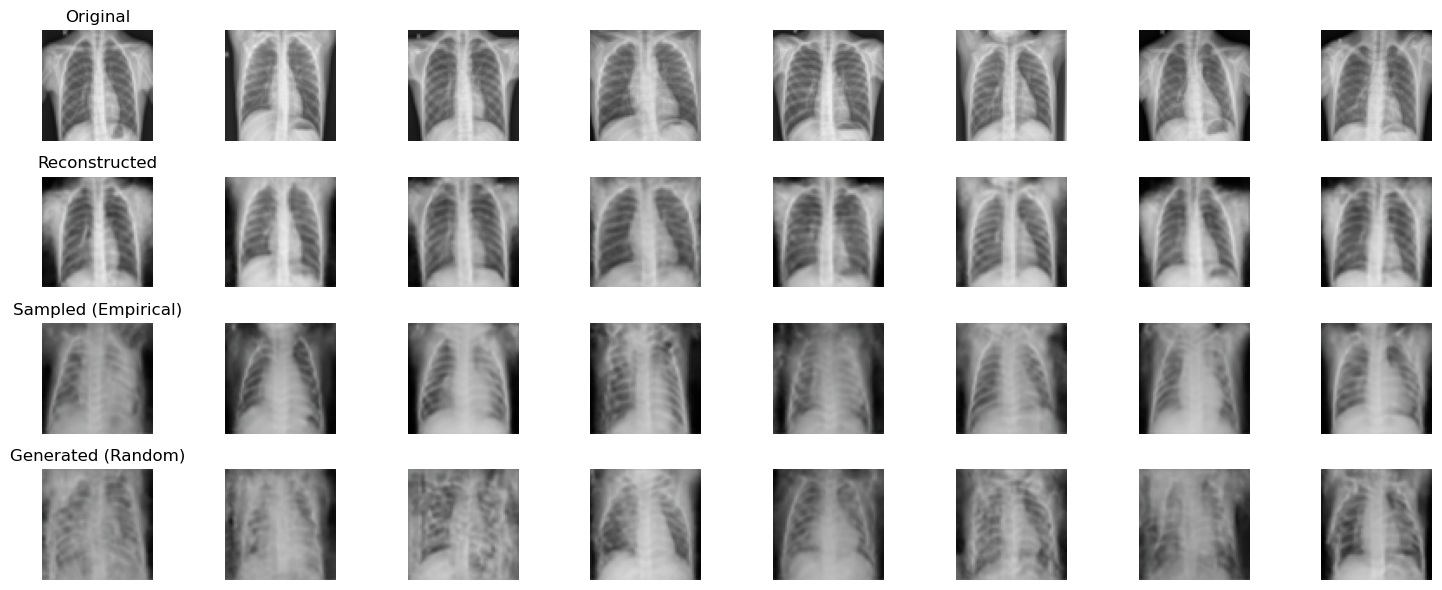

In [ ]:
import matplotlib.pyplot as plt
def visualize_results(model, loader, device, empirical_mean, empirical_std):
    model.eval()
    
    # get a batch of real images
    images, _ = next(iter(loader))
    images = images.to(device)
    batch_size = images.shape[0]
    
    with torch.no_grad():
        # Reconstructed Images
        recon_images, _, _ = model(images)
        
        # Sampled Images (using empirical distribution)
        z_sampled = torch.randn(batch_size, 512, device=device)
        z_sampled = (z_sampled * empirical_std.to(device)) + empirical_mean.to(device)
        sampled_images = decode_latent(model, z_sampled)
        
        # Randomly Generated Images (standard normal)
        z_random = torch.randn(batch_size, 512, device=device)
        random_images = decode_latent(model, z_random)

    images = images.cpu().numpy()
    recon_images = recon_images.cpu().numpy()
    sampled_images = sampled_images.cpu().numpy()
    random_images = random_images.cpu().numpy()
    
    fig, axes = plt.subplots(4, 8, figsize=(15, 6))
    titles = ["Original", "Reconstructed", "Sampled (Empirical)", "Generated (Random)"]
    data_sources = [images, recon_images, sampled_images, random_images]
    
    for row, (data, title) in enumerate(zip(data_sources, titles)):
        for col in range(8):
            img = np.transpose(data[col], (1, 2, 0))
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0: axes[row, col].set_title(title)

    plt.tight_layout()
    plt.show()

visualize_results(model, test_loader, device, empirical_mean, empirical_std)

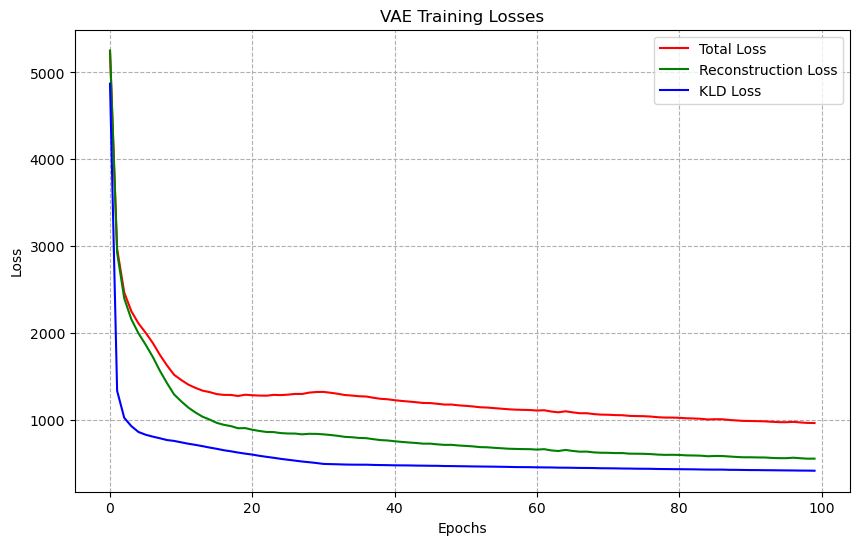

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(loss_history, label='Total Loss', color='red')
plt.plot(recons_hist, label='Reconstruction Loss', color='green')
plt.plot(KLDloss, label='KLD Loss', color='blue')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VAE Training Losses')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def evaluate_metrics(dataloader, generate_fn, device):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    inception = InceptionScore().to(device)

    with torch.no_grad():
        for batch in dataloader:
            real_images = batch[0] if isinstance(batch, (list, tuple)) else batch
            real_images = real_images.to(device)

            # generate image
            fake_images = generate_fn(real_images)

            real_images_8bit = (real_images * 255).to(torch.uint8)
            fake_images_8bit = (fake_images * 255).to(torch.uint8)
            fid.update(real_images_8bit, real=True)
            fid.update(fake_images_8bit, real=False)
            inception.update(fake_images_8bit) # IS only needs fake images

    fid = fid.cpu()
    inception = inception.cpu()

    fid_score = fid.compute().item()
    is_mean, is_std = inception.compute()

    fid.reset()
    inception.reset()

    print(f"FID: {fid_score:.4f} | IS: {is_mean.item():.4f} ± {is_std.item():.4f}\n")
    return fid_score, is_mean.item(), is_std.item()

In [26]:
# helper functions
def decode_latent(model, z):
    x = model.fc_de(z)
    x = x.view(x.size(0), 1024, 4, 4)
    return model.decoder(x)

def get_recon_images(model, real_images):
    recon, _, _ = model(real_images)
    return recon

def get_sampled_images(model, real_images, emp_mean, emp_std, device):
    batch_size = real_images.shape[0]
    z = torch.randn(batch_size, 512, device=device)
    z = (z * emp_std.to(device)) + emp_mean.to(device)
    return decode_latent(model, z)

def get_random_images(model, real_images, device):
    batch_size = real_images.shape[0]
    z = torch.randn(batch_size, 512, device=device)
    return decode_latent(model, z)

In [ ]:
model.eval()
print("Evalualtion Scores, FID & IS")
print("Reconstructed Images")
fid_recon, is_recon_mean, is_recon_std = evaluate_metrics(
        dataloader=test_loader,
        generate_fn=lambda real: get_recon_images(model, real),
        device=device
    )

print("--- Evaluating Sampled Images (Empirical Distribution) ---")
fid_samp, is_samp_mean, is_samp_std = evaluate_metrics(
        dataloader=test_loader,
        generate_fn=lambda real: get_sampled_images(model, real, empirical_mean, empirical_std, device),
        device=device
    )

print("--- Evaluating Randomly Generated Images (Standard Normal) ---")
fid_rand, is_rand_mean, is_rand_std = evaluate_metrics(
        dataloader=test_loader,
        generate_fn=lambda real: get_random_images(model, real, device),
        device=device
    )

Evalualtion Scores, FID & IS
Reconstructed Images
FID: 80.0589 | IS: 2.5792 ± 0.1963

--- Evaluating Sampled Images (Empirical Distribution) ---
FID: 141.1240 | IS: 2.6310 ± 0.1507

--- Evaluating Randomly Generated Images (Standard Normal) ---
FID: 252.2361 | IS: 2.4577 ± 0.0972



In [ ]:
import shutil
## dataset cache cleanup
print(f"Deleting cached data at: {path}")
shutil.rmtree(path)